# Simple Linear Regression: Housing Data

## Import Necessary Libaries
The code below imports all necessary libraries for the task.

In [1]:
import matplotlib

import matplotlib.pyplot as plt
import numpy as np
from sklearn import datasets, linear_model, metrics
from sklearn.model_selection import train_test_split
import pandas as pd

## Load Data
The code below loads the dataset from a CSV file into a pandas DataFrame.

In [ ]:
# Load dataset from a CSV file
# df = pd.read_csv("https://drive.google.com/uc?export=download&id=19IUeHxBI6hscqxe4UlAvXVDyOLJc4WYc")

df = pd.read_csv("data/linear regression/Housing.csv")

## Inspect Data - Head
The code below displays the first 5 rows of the DataFrame to inspect the data.

In [3]:
df.head(5)

,rownames,price,lotsize,bedrooms,bathrms,stories,driveway,recroom,fullbase,gashw,airco,garagepl,prefarea
0,1,42000,5850,3,1,2,yes,no,yes,no,no,1,no
1,2,38500,4000,2,1,1,yes,no,no,no,no,0,no
2,3,49500,3060,3,1,1,yes,no,no,no,no,0,no
3,4,60500,6650,3,1,2,yes,yes,no,no,no,0,no
4,5,61000,6360,2,1,1,yes,no,no,no,no,0,no


## Inspect Data - Tail
The code below displays the last 5 rows of the DataFrame to inspect the data.

In [4]:
df.tail(5)

,rownames,price,lotsize,bedrooms,bathrms,stories,driveway,recroom,fullbase,gashw,airco,garagepl,prefarea
541,542,91500,4800,3,2,4,yes,yes,no,no,yes,0,no
542,543,94000,6000,3,2,4,yes,no,no,no,yes,0,no
543,544,103000,6000,3,2,4,yes,yes,no,no,yes,1,no
544,545,105000,6000,3,2,2,yes,yes,no,no,yes,1,no
545,546,105000,6000,3,1,2,yes,no,no,no,yes,1,no


## Descriptive Statistics - Numerical
The code below provides descriptive statistics of the numerical columns in the DataFrame.

In [5]:
df.describe()

,rownames,price,lotsize,bedrooms,bathrms,stories,garagepl
count,546.000000,546.000000,546.000000,546.000000,546.000000,546.000000,546.000000
mean,273.500000,68121.597070,5150.265568,2.965201,1.285714,1.807692,0.692308
std,157.760895,26702.670926,2168.158725,0.737388,0.502158,0.868203,0.861307
min,1.000000,25000.000000,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,137.250000,49125.000000,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,273.500000,62000.000000,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,409.750000,82000.000000,6360.000000,3.000000,2.000000,2.000000,1.000000
max,546.000000,190000.000000,16200.000000,6.000000,4.000000,4.000000,3.000000


## Descriptive Statistics - All
The code below provides descriptive statistics of all columns in the DataFrame, including categorical ones.

In [6]:
summary = df.describe(include='all')
print(summary)

          rownames          price       lotsize    bedrooms     bathrms  \
count   546.000000     546.000000    546.000000  546.000000  546.000000   
unique         NaN            NaN           NaN         NaN         NaN   
top            NaN            NaN           NaN         NaN         NaN   
freq           NaN            NaN           NaN         NaN         NaN   
mean    273.500000   68121.597070   5150.265568    2.965201    1.285714   
std     157.760895   26702.670926   2168.158725    0.737388    0.502158   
min       1.000000   25000.000000   1650.000000    1.000000    1.000000   
25%     137.250000   49125.000000   3600.000000    2.000000    1.000000   
50%     273.500000   62000.000000   4600.000000    3.000000    1.000000   
75%     409.750000   82000.000000   6360.000000    3.000000    2.000000   
max     546.000000  190000.000000  16200.000000    6.000000    4.000000   

           stories driveway recroom fullbase gashw airco    garagepl prefarea  
count   546.000000 

## Data Information
The code below displays information about the DataFrame, including the data types and non-null counts of each column.

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 546 entries, 0 to 545
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   rownames  546 non-null    int64 
 1   price     546 non-null    int64 
 2   lotsize   546 non-null    int64 
 3   bedrooms  546 non-null    int64 
 4   bathrms   546 non-null    int64 
 5   stories   546 non-null    int64 
 6   driveway  546 non-null    object
 7   recroom   546 non-null    object
 8   fullbase  546 non-null    object
 9   gashw     546 non-null    object
 10  airco     546 non-null    object
 11  garagepl  546 non-null    int64 
 12  prefarea  546 non-null    object
dtypes: int64(7), object(6)
memory usage: 55.6+ KB


## Column Names
The code below displays the column names of the DataFrame.

In [8]:
df.columns

Index(['rownames', 'price', 'lotsize', 'bedrooms', 'bathrms', 'stories',
       'driveway', 'recroom', 'fullbase', 'gashw', 'airco', 'garagepl',
       'prefarea'],
      dtype='object')

## Feature and Target Variable Extraction
The code below extracts the 'price' column as the target variable (Y) and the 'lotsize' column as the feature (X).

In [9]:
# Extract features and target variable
Y = df['price']
X = df['lotsize']

## Reshape Data
The code below reshapes the feature and target variable arrays for compatibility with scikit-learn, which expects a 2D array for features.

In [10]:
# Reshape for compatibility with scikit-learn
X = X.to_numpy().reshape(len(X), 1)
Y = Y.to_numpy().reshape(len(Y), 1)

## Split Data (Manual)
The code below splits the data into training and testing sets.

In [11]:
# Split data into training and testing sets
X_train = X[:-250]
X_test = X[-250:]
Y_train = Y[:-250]
Y_test = Y[-250:]

## Split Data (train_test_split)
The code below splits the data into training and testing sets using `train_test_split` from scikit-learn, with a test size of 20% and a fixed random state for reproducibility.

In [12]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

## Plot Training Data
The code below plots the training data as a scatter plot to visualize the relationship between 'lotsize' and 'price'.

([], [])

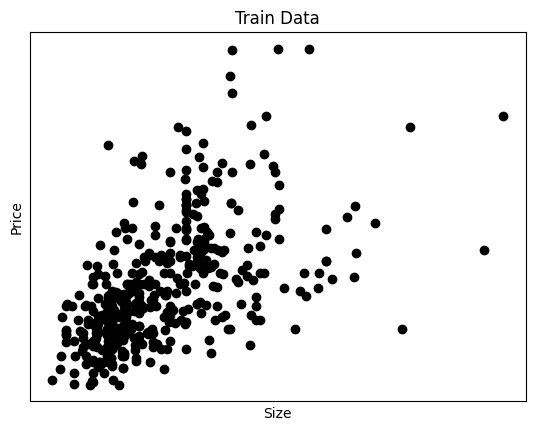

In [13]:
# Plot the train data
plt.scatter(X_train, Y_train, color='black')
plt.title('Train Data')
plt.xlabel('Size')
plt.ylabel('Price')
plt.xticks(())
plt.yticks(())

## Plot Testing Data
The code below plots the testing data as a scatter plot to visualize the relationship between 'lotsize' and 'price'.

([], [])

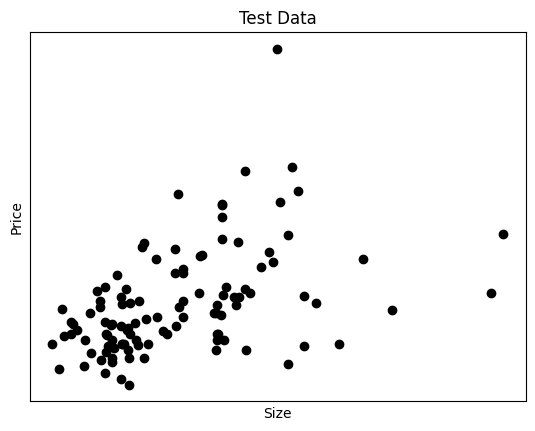

In [14]:
# Plot the test data
plt.scatter(X_test, Y_test, color='black')
plt.title('Test Data')
plt.xlabel('Size')
plt.ylabel('Price')
plt.xticks(())
plt.yticks(())

## Train Model
The code below trains a linear regression model using the training data.

In [15]:
# Train linear regression model
sim_regr = linear_model.LinearRegression()
sim_regr.fit(X_train, Y_train)

LinearRegression()

## Make Predictions
The code below makes predictions on the test data using the trained linear regression model.

In [16]:
predict = sim_regr.predict(X_test)

## Plot Predictions
The code below plots the test data and the linear regression line representing the model's predictions.

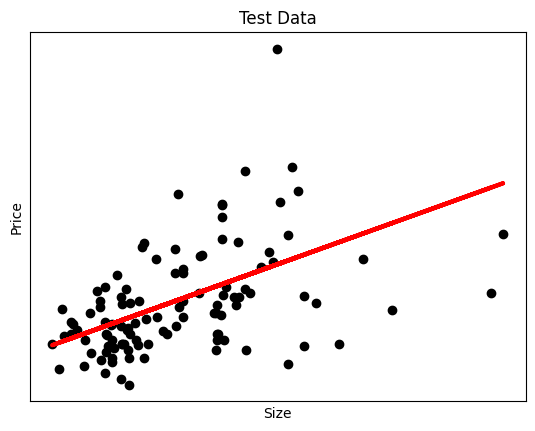

In [17]:
# Plot predictions
plt.scatter(X_test, Y_test, color='black')
plt.title('Test Data')
plt.xlabel('Size')
plt.ylabel('Price')
plt.xticks(())
plt.yticks(())
plt.plot(X_test, sim_regr.predict(X_test), color='red', linewidth=3)
plt.show()

## Calculate RMSE
The code below calculates the Root Mean Squared Error (RMSE) of the model's predictions on the test data.

In [18]:
rmse = np.sqrt(np.mean((predict - Y_test)**2))
rmse

np.float64(23322.118783664337)

## Calculate R-squared
The code below calculates the R-squared score of the model on the test data, which represents the proportion of the variance in the dependent variable that is predictable from the independent variable.

In [19]:
r2 = sim_regr.score(X_test, Y_test)
r2

0.18583856088525563

## Model Performance and Next Steps

Based on the evaluation metrics:

*   **RMSE (Root Mean Squared Error):** `np.float64(23322.118783664337)`
*   **R-squared:** `0.18583856088525563`

The RMSE indicates that, on average, the model's predictions are off by approximately $23,322. This value should be interpreted in the context of the price range of the houses in the dataset. The R-squared value of approximately 0.186 suggests that only about 18.6% of the variance in the house prices can be explained by the 'lotsize' feature alone. This indicates that 'lotsize' is not a strong predictor of house price in this dataset, and the simple linear regression model is not performing very well.

To improve the prediction performance, consider the following steps:

1.  **Feature Engineering:** Explore other features in the dataset that might have a stronger correlation with 'price'. Consider including multiple features in a multiple linear regression model.
2.  **Handling Categorical Features:** Convert the categorical features (like 'driveway', 'recroom', etc.) into numerical format using techniques like one-hot encoding.
3.  **Feature Selection:** Use techniques to select the most relevant features for predicting house price.
4.  **More Complex Models:** If a linear model is not sufficient, explore other regression algorithms such as polynomial regression, decision trees, random forests, or gradient boosting.
5.  **Data Scaling:** Scale numerical features to have a similar range, which can improve the performance of some models.
6.  **Outlier Detection and Handling:** Identify and handle outliers in the data that might be skewing the model.

Analyze the housing dataset from "https://www.kaggle.com/datasets/shreetamam/housing-price-data" to demonstrate how feature engineering, handling categorical features, and feature selection can improve the performance of a multiple linear regression model compared to a simple linear regression model, suitable for teaching beginners in data science.

# Multiple Linear Regression

## Load the dataset
Load the housing dataset from the specified URL into a pandas DataFrame.


In [ ]:
# Check the first few rows
# df = pd.read_csv("https://drive.google.com/uc?export=download&id=19IUeHxBI6hscqxe4UlAvXVDyOLJc4WYc")

df = pd.read_csv("data/linear regression/Housing.csv")

## Explore the dataset


In [21]:
print(df.head())

   rownames  price  lotsize  bedrooms  bathrms  stories driveway recroom  \
0         1  42000     5850         3        1        2      yes      no   
1         2  38500     4000         2        1        1      yes      no   
2         3  49500     3060         3        1        1      yes      no   
3         4  60500     6650         3        1        2      yes     yes   
4         5  61000     6360         2        1        1      yes      no   

  fullbase gashw airco  garagepl prefarea  
0      yes    no    no         1       no  
1       no    no    no         0       no  
2       no    no    no         0       no  
3       no    no    no         0       no  
4       no    no    no         0       no  


In [22]:
# Get information about the columns (data types and missing values)
print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 546 entries, 0 to 545
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   rownames  546 non-null    int64 
 1   price     546 non-null    int64 
 2   lotsize   546 non-null    int64 
 3   bedrooms  546 non-null    int64 
 4   bathrms   546 non-null    int64 
 5   stories   546 non-null    int64 
 6   driveway  546 non-null    object
 7   recroom   546 non-null    object
 8   fullbase  546 non-null    object
 9   gashw     546 non-null    object
 10  airco     546 non-null    object
 11  garagepl  546 non-null    int64 
 12  prefarea  546 non-null    object
dtypes: int64(7), object(6)
memory usage: 55.6+ KB
None


In [23]:
# Get descriptive statistics for numerical columns
print(df.describe())


         rownames          price       lotsize    bedrooms     bathrms  \
count  546.000000     546.000000    546.000000  546.000000  546.000000   
mean   273.500000   68121.597070   5150.265568    2.965201    1.285714   
std    157.760895   26702.670926   2168.158725    0.737388    0.502158   
min      1.000000   25000.000000   1650.000000    1.000000    1.000000   
25%    137.250000   49125.000000   3600.000000    2.000000    1.000000   
50%    273.500000   62000.000000   4600.000000    3.000000    1.000000   
75%    409.750000   82000.000000   6360.000000    3.000000    2.000000   
max    546.000000  190000.000000  16200.000000    6.000000    4.000000   

          stories    garagepl  
count  546.000000  546.000000  
mean     1.807692    0.692308  
std      0.868203    0.861307  
min      1.000000    0.000000  
25%      1.000000    0.000000  
50%      2.000000    0.000000  
75%      2.000000    1.000000  
max      4.000000    3.000000  


In [24]:
# Check for missing values
print(df.isnull().sum())

rownames    0
price       0
lotsize     0
bedrooms    0
bathrms     0
stories     0
driveway    0
recroom     0
fullbase    0
gashw       0
airco       0
garagepl    0
prefarea    0
dtype: int64


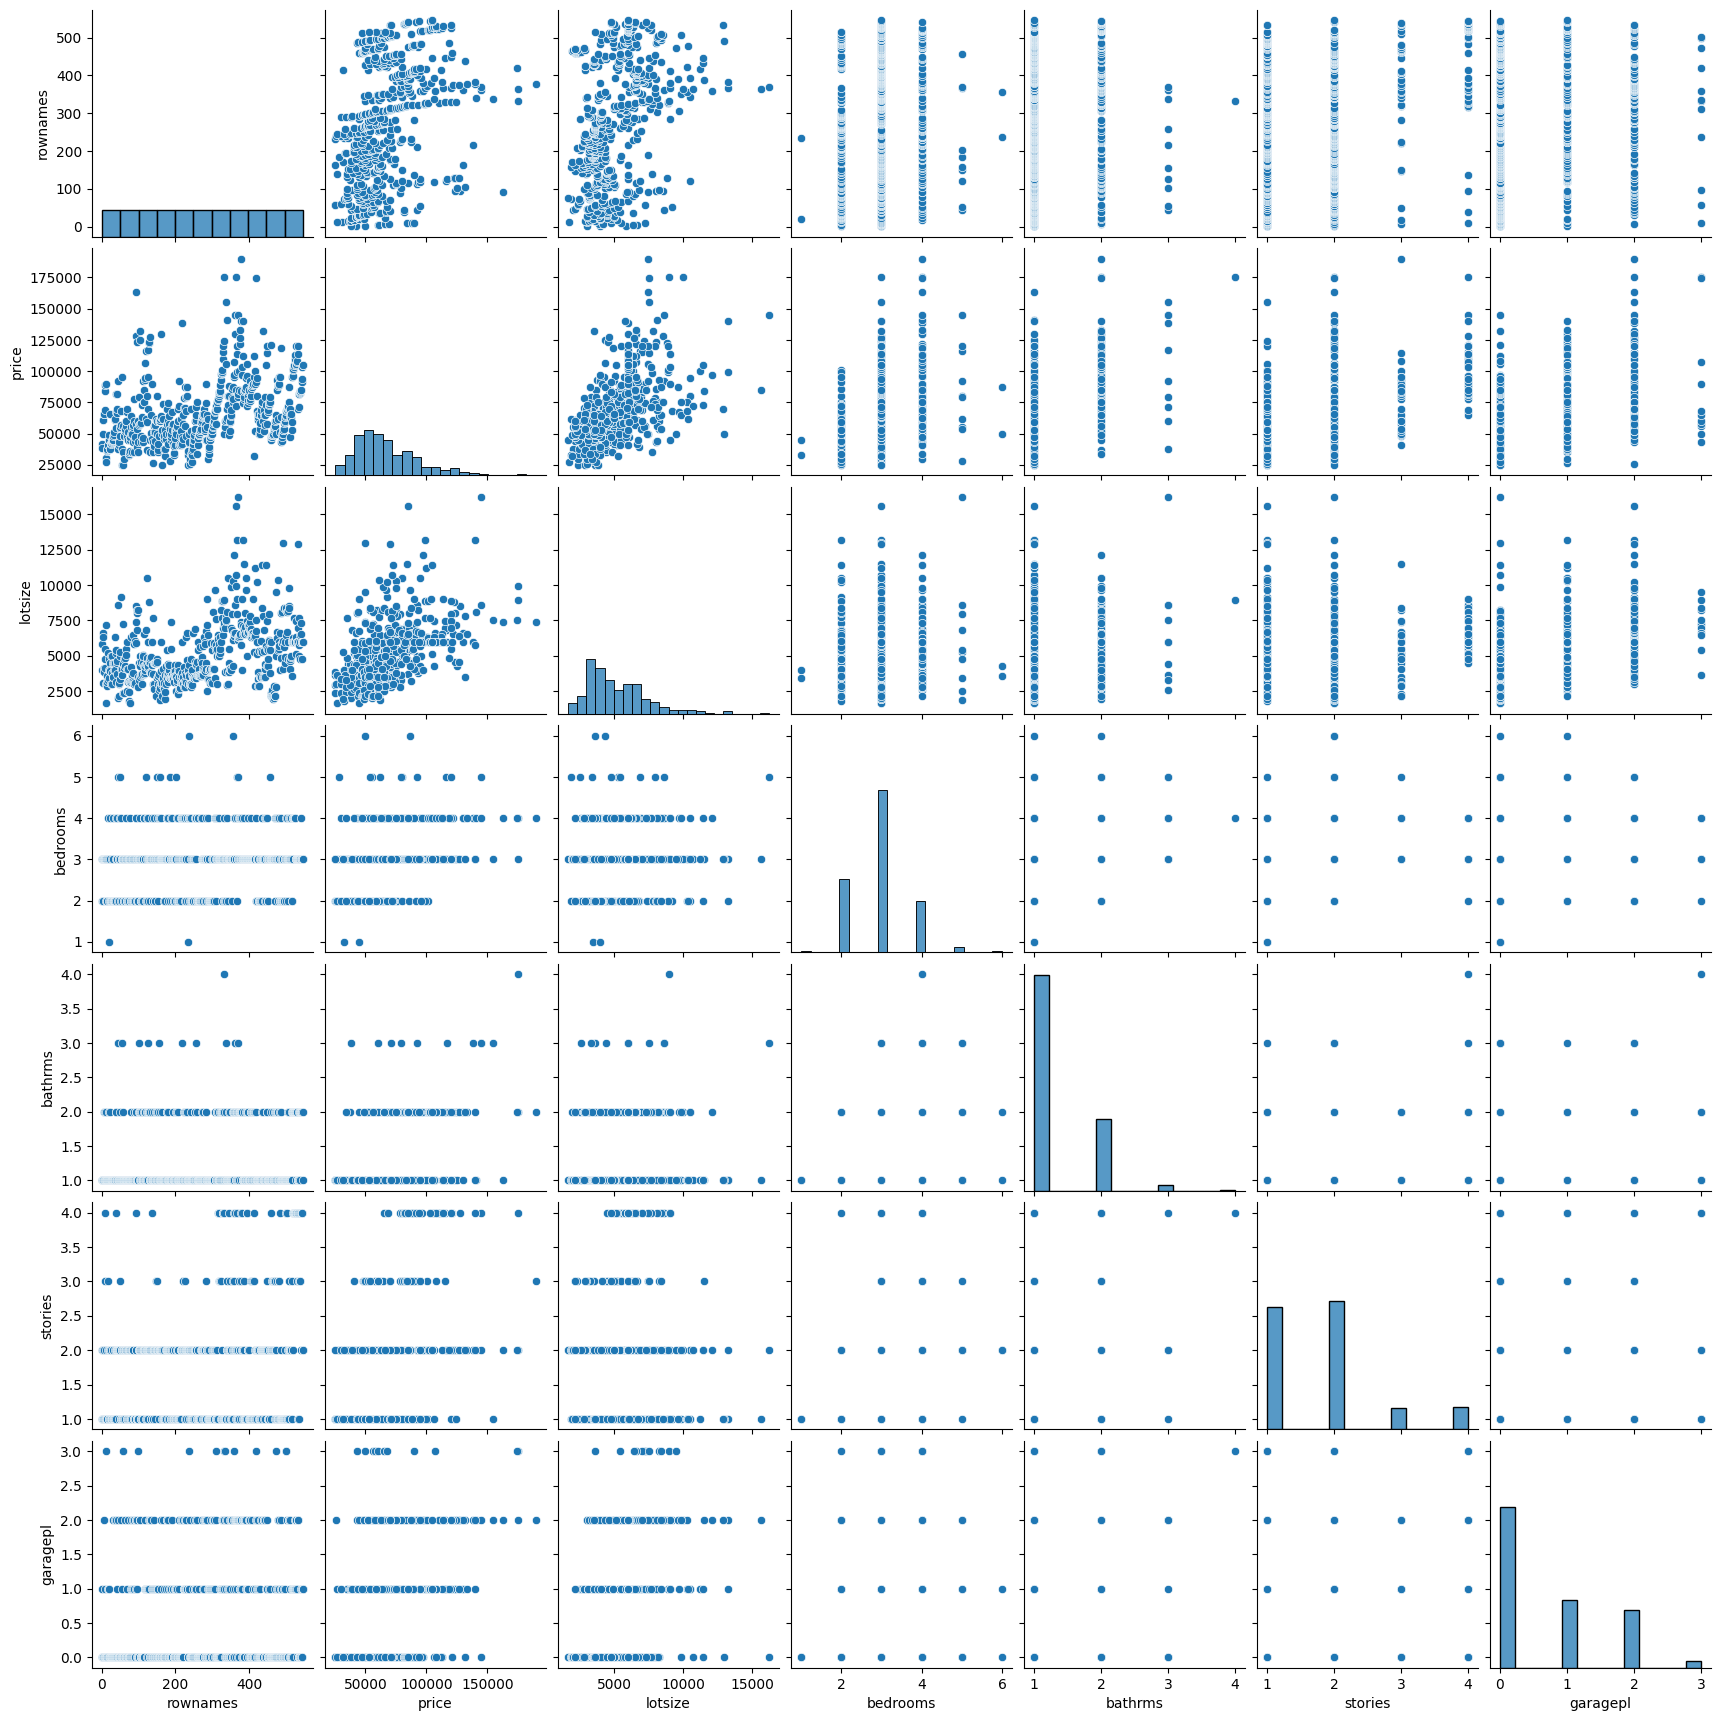

In [25]:
# Plot all metric against Price to visually understand linear relationship
import seaborn as sns
import matplotlib.pyplot as plt

sns.pairplot(df)
plt.show()

In [26]:
# Identify categorical columns
categorical_cols = df.select_dtypes(include='object').columns
print("\nCategorical features:", categorical_cols.tolist())


Categorical features: ['driveway', 'recroom', 'fullbase', 'gashw', 'airco', 'prefarea']


In [27]:
# Identify numerical columns
numerical_cols = df.select_dtypes(include=np.number).columns
print("Numerical features:", numerical_cols.tolist())

Numerical features: ['rownames', 'price', 'lotsize', 'bedrooms', 'bathrms', 'stories', 'garagepl']


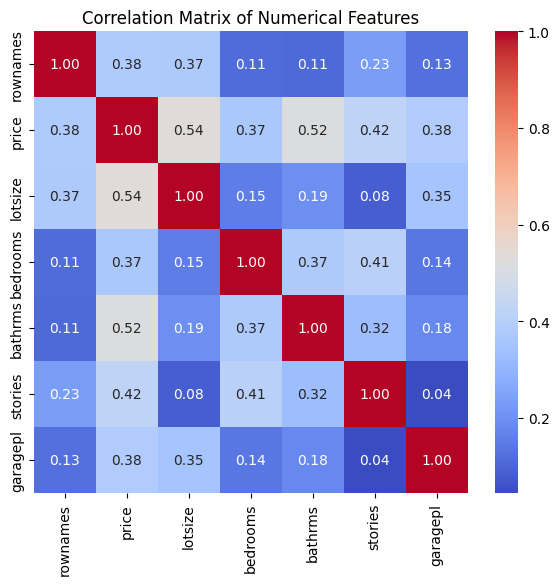

In [28]:
import seaborn as sns # For enhanced plotting
numerical_df = df[numerical_cols]
correlation_matrix = numerical_df.corr()

plt.figure(figsize=(7, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.show()


## Handle categorical features

Convert the categorical features in the dataset into a numerical format suitable for machine learning models using one-hot encoding.


In [29]:
df_encoded_1 = pd.get_dummies(df, columns=categorical_cols)
df_encoded_1

,rownames,price,lotsize,bedrooms,bathrms,stories,garagepl,driveway_no,driveway_yes,recroom_no,recroom_yes,fullbase_no,fullbase_yes,gashw_no,gashw_yes,airco_no,airco_yes,prefarea_no,prefarea_yes
0,1,42000,5850,3,1,2,1,False,True,True,False,False,True,True,False,True,False,True,False
1,2,38500,4000,2,1,1,0,False,True,True,False,True,False,True,False,True,False,True,False
2,3,49500,3060,3,1,1,0,False,True,True,False,True,False,True,False,True,False,True,False
3,4,60500,6650,3,1,2,0,False,True,False,True,True,False,True,False,True,False,True,False
4,5,61000,6360,2,1,1,0,False,True,True,False,True,False,True,False,True,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
541,542,91500,4800,3,2,4,0,False,True,False,True,True,False,True,False,False,True,True,False
542,543,94000,6000,3,2,4,0,False,True,True,False,True,False,True,False,False,True,True,False
543,544,103000,6000,3,2,4,1,False,True,False,True,True,False,True,False,False,True,True,False
544,545,105000,6000,3,2,2,1,False,True,False,True,True,False,True,False,False,True,True,False


In [30]:
df.head()

,rownames,price,lotsize,bedrooms,bathrms,stories,driveway,recroom,fullbase,gashw,airco,garagepl,prefarea
0,1,42000,5850,3,1,2,yes,no,yes,no,no,1,no
1,2,38500,4000,2,1,1,yes,no,no,no,no,0,no
2,3,49500,3060,3,1,1,yes,no,no,no,no,0,no
3,4,60500,6650,3,1,2,yes,yes,no,no,no,0,no
4,5,61000,6360,2,1,1,yes,no,no,no,no,0,no


In [31]:
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

In [32]:
display(df_encoded.head())

,rownames,price,lotsize,bedrooms,bathrms,stories,garagepl,driveway_yes,recroom_yes,fullbase_yes,gashw_yes,airco_yes,prefarea_yes
0,1,42000,5850,3,1,2,1,True,False,True,False,False,False
1,2,38500,4000,2,1,1,0,True,False,False,False,False,False
2,3,49500,3060,3,1,1,0,True,False,False,False,False,False
3,4,60500,6650,3,1,2,0,True,True,False,False,False,False
4,5,61000,6360,2,1,1,0,True,False,False,False,False,False


In [33]:
df_encoded_test = pd.get_dummies(df, columns=categorical_cols)
display(df_encoded_test.head())

,rownames,price,lotsize,bedrooms,bathrms,stories,garagepl,driveway_no,driveway_yes,recroom_no,recroom_yes,fullbase_no,fullbase_yes,gashw_no,gashw_yes,airco_no,airco_yes,prefarea_no,prefarea_yes
0,1,42000,5850,3,1,2,1,False,True,True,False,False,True,True,False,True,False,True,False
1,2,38500,4000,2,1,1,0,False,True,True,False,True,False,True,False,True,False,True,False
2,3,49500,3060,3,1,1,0,False,True,True,False,True,False,True,False,True,False,True,False
3,4,60500,6650,3,1,2,0,False,True,False,True,True,False,True,False,True,False,True,False
4,5,61000,6360,2,1,1,0,False,True,True,False,True,False,True,False,True,False,True,False


## Feature engineering

Create new features that might be more informative for predicting house prices (e.g., interaction terms, polynomial features).


- ```lotsize_bedrooms:``` This new feature is created by multiplying the lotsize (size of the lot) by the number of bedrooms. It's an interaction term that might capture the idea that the value of a larger lot could be influenced by having more bedrooms, or vice versa.
- ```lotsize_sq:``` This feature is the lotsize squared. It's a polynomial feature that can help the linear model capture a non-linear relationship between lotsize and price. Sometimes, the effect of lot size on price isn't purely linear; a very large lot might have a disproportionately higher price than just a linearly scaled price based on size.
- ```bathrms_stories:``` This is another interaction term, calculated by multiplying the number of bathrms by the number of stories. It could reflect that the combined effect of having multiple bathrooms and multiple stories might be more valuable than the sum of their individual effects.

These engineered features are attempts to provide the model with more information and potentially better capture the underlying relationships in the data, which can lead to improved prediction performance.

In [34]:
df_encoded['lotsize_bedrooms'] = df_encoded['lotsize'] * df_encoded['bedrooms']
df_encoded['lotsize_sq'] = df_encoded['lotsize']**2
df_encoded['bathrms_stories'] = df_encoded['bathrms'] * df_encoded['stories']
display(df_encoded.head())

,rownames,price,lotsize,bedrooms,bathrms,stories,garagepl,driveway_yes,recroom_yes,fullbase_yes,gashw_yes,airco_yes,prefarea_yes,lotsize_bedrooms,lotsize_sq,bathrms_stories
0,1,42000,5850,3,1,2,1,True,False,True,False,False,False,17550,34222500,2
1,2,38500,4000,2,1,1,0,True,False,False,False,False,False,8000,16000000,1
2,3,49500,3060,3,1,1,0,True,False,False,False,False,False,9180,9363600,1
3,4,60500,6650,3,1,2,0,True,True,False,False,False,False,19950,44222500,2
4,5,61000,6360,2,1,1,0,True,False,False,False,False,False,12720,40449600,1


## Feature selection

Select a subset of the most relevant features to use for the multiple linear regression model to avoid overfitting and improve interpretability.


Define the target variable Y and the feature set X from the df_encoded DataFrame.



In [35]:
Y = df_encoded['price']
X = df_encoded.drop(['price', 'rownames'], axis=1)
display(X.head())
display(Y.head())

,lotsize,bedrooms,bathrms,stories,garagepl,driveway_yes,recroom_yes,fullbase_yes,gashw_yes,airco_yes,prefarea_yes,lotsize_bedrooms,lotsize_sq,bathrms_stories
0,5850,3,1,2,1,True,False,True,False,False,False,17550,34222500,2
1,4000,2,1,1,0,True,False,False,False,False,False,8000,16000000,1
2,3060,3,1,1,0,True,False,False,False,False,False,9180,9363600,1
3,6650,3,1,2,0,True,True,False,False,False,False,19950,44222500,2
4,6360,2,1,1,0,True,False,False,False,False,False,12720,40449600,1


,price
0,42000
1,38500
2,49500
3,60500
4,61000


## Split the data



Split the feature set X and the target variable Y into training and testing sets using train_test_split with a test size of 0.2 and a random state of 42.



In [36]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [37]:
X.shape

(546, 14)

In [38]:
Y.shape

(546,)

In [39]:
X_train.shape

(436, 14)

In [40]:
X_test.shape


(110, 14)

In [41]:
Y_train.shape

(436,)

In [42]:
Y_test.shape

(110,)

## Train a multiple linear regression model


Train a linear regression model using the selected features on the training data.



In [43]:
from sklearn.linear_model import LinearRegression
regr = LinearRegression()
regr.fit(X_train, Y_train)

LinearRegression()

# Combine Prediction and Actual with features for understanding

In [53]:
X_test[:5]

,lotsize,bedrooms,bathrms,stories,garagepl,driveway_yes,recroom_yes,fullbase_yes,gashw_yes,airco_yes,prefarea_yes,lotsize_bedrooms,lotsize_sq,bathrms_stories
316,5000,3,1,4,0,True,False,False,False,False,False,15000,25000000,4
77,3180,4,1,2,0,True,False,True,False,True,False,12720,10112400,2
360,6600,4,2,2,1,True,True,True,False,True,True,26400,43560000,4
90,6060,3,1,1,0,True,True,True,False,False,False,18180,36723600,1
495,5985,3,1,1,0,True,False,True,False,False,False,17955,35820225,1


In [54]:
Y_pred = regr.predict(X_test)

In [55]:
Y_pred[:5]

array([ 67422.45111307,  64592.29412155, 111277.72287434,  62534.61987775,
        58880.36387773])

In [56]:
Y_test[:5]

,price
316,80000
77,47000
360,130000
90,47000
495,59000


In [44]:
Y_pred = regr.predict(X_test)
final_df = pd.DataFrame({'Actual': Y_test, 'Predicted': Y_pred})
final_df = final_df.merge(X_test, left_index=True, right_index=True)
column_order = [col for col in final_df.columns if col not in ['Actual', 'Predicted']] + ['Actual', 'Predicted']
final_df = final_df[column_order]
display(final_df.head())

,lotsize,bedrooms,bathrms,stories,garagepl,driveway_yes,recroom_yes,fullbase_yes,gashw_yes,airco_yes,prefarea_yes,lotsize_bedrooms,lotsize_sq,bathrms_stories,Actual,Predicted
316,5000,3,1,4,0,True,False,False,False,False,False,15000,25000000,4,80000,67422.451113
77,3180,4,1,2,0,True,False,True,False,True,False,12720,10112400,2,47000,64592.294122
360,6600,4,2,2,1,True,True,True,False,True,True,26400,43560000,4,130000,111277.722874
90,6060,3,1,1,0,True,True,True,False,False,False,18180,36723600,1,47000,62534.619878
495,5985,3,1,1,0,True,False,True,False,False,False,17955,35820225,1,59000,58880.363878


## Evaluate the model

Evaluate the performance of the multiple linear regression model on the test data using appropriate metrics like RMSE and R-squared.


**Reasoning**:
The previous code failed because `np` was not defined. I need to import `numpy` to fix this error.



In [45]:
from sklearn.metrics import mean_squared_error
import numpy as np

Y_pred = regr.predict(X_test)
rmse = np.sqrt(mean_squared_error(Y_test, Y_pred))
r2 = regr.score(X_test, Y_test)

print(f"RMSE: {rmse}")
print(f"R-squared: {r2}")

RMSE: 15817.939352262723
R-squared: 0.6254805858124355


## Compare simple vs. multiple linear regression

### Subtask:
Compare the performance of the simple linear regression model (from the previous notebook) with the multiple linear regression model to demonstrate the impact of the steps taken.


**Reasoning**:
Print the RMSE and R-squared values from the simple linear regression model and the multiple linear regression model for comparison.



In [46]:
print("Simple Linear Regression Model Performance:")
print(f"RMSE: {np.float64(23322.118783664337)}")
print(f"R-squared: {0.18583856088525563}")
print("\nMultiple Linear Regression Model Performance:")
print(f"RMSE: {rmse}")
print(f"R-squared: {r2}")

Simple Linear Regression Model Performance:
RMSE: 23322.118783664337
R-squared: 0.18583856088525563

Multiple Linear Regression Model Performance:
RMSE: 15817.939352262723
R-squared: 0.6254805858124355


In [47]:
print(sim_regr.coef_)
print(sim_regr.intercept_)

[[6.88540888]]
[33003.3621689]


In [48]:
print(regr.coef_)
print(regr.intercept_)

[ 3.42301842e+00 -3.97010850e+03  9.91504425e+03  5.31433870e+03
  4.51321393e+03  6.36679500e+03  3.36268204e+03  7.02873886e+03
  1.54396248e+04  1.25031396e+04  7.81422993e+03  1.05118455e+00
 -2.23239453e-04  1.23007745e+03]
9571.39872429685


## Summary:

### Data Analysis Key Findings

*   The dataset contains both numerical and categorical features, with no missing values.
*   One-hot encoding was successfully applied to the categorical features to convert them into a numerical format, using `drop_first=True` to avoid multicollinearity.
*   New features were engineered, including interaction terms (`lotsize_bedrooms`, `bathrms_stories`) and a polynomial term (`lotsize_sq`), to potentially capture more complex relationships in the data.
*   The dataset was split into training (80%) and testing (20%) sets using a `random_state` of 42 for reproducibility.
*   A multiple linear regression model was trained on the engineered features and one-hot encoded categorical variables.
*   The multiple linear regression model achieved an RMSE of approximately 15817.94 and an R-squared of approximately 0.625 on the test set.
*   Compared to a simple linear regression model (with RMSE ~23322.12 and R-squared ~0.186), the multiple linear regression model showed significantly improved performance, with a lower RMSE and a higher R-squared value.

### Insights or Next Steps

*   The substantial improvement in model performance demonstrates the value of feature engineering, handling categorical variables, and potentially feature selection for building more effective predictive models.
*   Further exploration could involve trying different feature engineering techniques, exploring other feature selection methods, or evaluating more advanced regression models to potentially achieve even better performance.


In [49]:
# prompt: Write code to pickle model

import pickle

# Define the filename for the pickled model
filename = 'multiple_linear_regression_model.pkl'

# Save the trained model to a file
pickle.dump(regr, open(filename, 'wb'))

print(f"Model successfully pickled and saved as {filename}")

Model successfully pickled and saved as multiple_linear_regression_model.pkl


In [50]:
# Load the pickled model
loaded_model = pickle.load(open('multiple_linear_regression_model.pkl', 'rb'))

# Use the loaded model to make predictions
loaded_model_predictions = loaded_model.predict(X_test)

In [51]:
# prompt: Write code to pickle the model and again reuse the pick to create model object

import numpy as np
import pickle

# Define the filename for the pickle file
filename = 'linear_regression_model.pkl'

# Pickle the trained model
pickle.dump(regr, open(filename, 'wb'))

# Load the pickled model
loaded_model = pickle.load(open(filename, 'rb'))

# Use the loaded model to make predictions
loaded_model_predictions = loaded_model.predict(X_test)

# Optionally, compare predictions from original and loaded models to verify
np.array_equal(Y_pred, loaded_model_predictions)

True

# Statistical Model

In [52]:
import statsmodels.api as sm

# Convert boolean columns to integers
X_train = X_train.astype(int)

# Add a constant to the features matrix for statsmodels
X_train_sm = sm.add_constant(X_train)

# Create and fit the OLS model
model = sm.OLS(Y_train, X_train_sm).fit()

# Print the summary
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.689
Model:                            OLS   Adj. R-squared:                  0.678
Method:                 Least Squares   F-statistic:                     66.51
Date:                Mon, 25 Aug 2025   Prob (F-statistic):           3.07e-97
Time:                        03:58:09   Log-Likelihood:                -4810.2
No. Observations:                 436   AIC:                             9650.
Df Residuals:                     421   BIC:                             9712.
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const             9571.3987   9159.651  

## Statistical Model Analysis (using Statsmodels)

The `statsmodels` library provides a detailed statistical summary of the linear regression model, which goes beyond the basic performance metrics (RMSE and R-squared) offered by scikit-learn. Here's an explanation of the key components of the summary table:

*   **R-squared and Adj. R-squared:**
    *   **R-squared:** This is the same R-squared value we saw with scikit-learn, representing the proportion of the variance in the target variable ('price') that is explained by the features in the model. In our case, it's approximately 0.689.
    *   **Adj. R-squared:** This is the adjusted R-squared, which accounts for the number of predictors. It's a more reliable metric for comparing models with different numbers of features. Our adjusted R-squared is approximately 0.678, which is very close to the R-squared, indicating that the added features are indeed contributing to the model.

*   **F-statistic and Prob (F-statistic):**
    *   **F-statistic:** This is a measure of the overall significance of the regression model. It tests whether at least one of the predictors has a non-zero coefficient.
    *   **Prob (F-statistic):** This is the p-value associated with the F-statistic. A very low p-value (typically less than 0.05) indicates that the overall model is statistically significant, meaning that the features collectively have a significant impact on the target variable. Our Prob (F-statistic) is very close to 0, indicating that our model is statistically significant.

*   **Coef.:** These are the estimated coefficients for each feature in the model. They represent the change in the mean of the target variable for a one-unit increase in the corresponding feature, holding all other features constant. The `const` is the intercept of the model.

*   **Std. Err.:** These are the standard errors of the coefficients. They measure the variability of the coefficient estimates.

*   **t:** These are the t-statistics for each coefficient. They are used to test the hypothesis that the true coefficient is zero.

*   **P>|t|:** These are the p-values for each coefficient. A low p-value (typically less than 0.05) indicates that the corresponding feature is statistically significant, meaning it is likely to have a real impact on the target variable. Looking at the p-values, features like 'lotsize', 'bathrms', 'stories', 'garagepl', 'driveway\_yes', 'fullbase\_yes', 'gashw\_yes', 'airco\_yes', 'prefarea\_yes', 'lotsize\_bedrooms', and 'lotsize\_sq' appear to be statistically significant. 'bedrooms' and 'recroom\_yes' have p-values slightly above 0.05, suggesting they might be less statistically significant in this model. 'bathrms\_stories' has a high p-value, indicating it is not statistically significant.

*   **[0.025 0.975]:** These are the 95% confidence intervals for each coefficient. They provide a range of values within which the true coefficient is likely to fall.

*   **Omnibus, Prob(Omnibus), Jarque-Bera (JB), Prob(JB), Skew, and Kurtosis:** These are tests for the normality of the residuals (the differences between the observed and predicted values). Significant results here (low p-values) suggest that the residuals are not normally distributed, which can indicate issues with the model assumptions. Our Prob(Omnibus) and Prob(JB) are very low, suggesting non-normally distributed residuals.

*   **Durbin-Watson:** This statistic tests for the presence of autocorrelation in the residuals. A value close to 2 indicates no autocorrelation. Values significantly less than 2 suggest positive autocorrelation, and values significantly greater than 2 suggest negative autocorrelation. Our Durbin-Watson value is 2.061, which is close to 2, suggesting no significant autocorrelation.

*   **Cond. No.:** This is the condition number, which assesses multicollinearity (high correlation between predictor variables). A high condition number (typically above 30) suggests significant multicollinearity, which can make it difficult to interpret the individual coefficients. Our condition number is very high (5.78e+08), indicating strong multicollinearity. This is likely due to the engineered features like `lotsize_sq` and `lotsize_bedrooms` being highly correlated with `lotsize`, and potentially `bathrms_stories` with `bathrms` and `stories`. While multicollinearity doesn't necessarily impact the model's predictive power, it makes it harder to determine the individual impact of each correlated feature.

**In summary, the `statsmodels` output confirms that our multiple linear regression model is statistically significant and that several features have a significant impact on house prices. However, the high condition number suggests multicollinearity, which is important to be aware of when interpreting the individual coefficients.**